In [1]:
import pandas as pd
import numpy as np
import torch
import tensorflow as tf
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
# Load the dataset
data = pd.read_csv("classast - pha1.csv")

# Encode target variable
label_encoder = LabelEncoder()
data['class'] = label_encoder.fit_transform(data['class'])

# Separate features and target
X = data.drop("class", axis=1).values
y = data["class"].values

# Find the minimum number of samples in any class in the training data
min_samples = np.bincount(y).min()

# Set k_neighbors to min_samples - 1 if min_samples is less than the default 5
k_neighbors = min(min_samples - 1, 5) if min_samples > 1 else 1

# Apply SMOTE with the adjusted k_neighbors
smote = SMOTE(random_state=42, k_neighbors=k_neighbors)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_resampled, dtype=torch.long)

# Create dataset and split into train/test sets
train_X, test_X, train_y, test_y = train_test_split(
    X_tensor, y_tensor, test_size=0.2, stratify=y_resampled, random_state=42)

train_dataset = TensorDataset(train_X, train_y)
test_dataset = TensorDataset(test_X, test_y)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [3]:
!pip install pytorch-tabnet

# New section

In [4]:
# Train and Evaluate TabNet
from pytorch_tabnet.tab_model import TabNetClassifier

# Initialize TabNet Classifier
clf_tabnet = TabNetClassifier()

# Fit the model on the training data
clf_tabnet.fit(
    train_X.numpy(),
    train_y.numpy(),
    eval_set=[(test_X.numpy(), test_y.numpy())],
    max_epochs=200,
    patience=20
)

# Predict on the test data
y_pred_tabnet = clf_tabnet.predict(test_X.numpy())

# Evaluation Metrics
print("\nTabNet Results:")
print(f"Accuracy:  {accuracy_score(test_y.numpy(), y_pred_tabnet):.4f}")
print(f"Precision: {precision_score(test_y.numpy(), y_pred_tabnet, average='weighted'):.4f}")
print(f"Recall:    {recall_score(test_y.numpy(), y_pred_tabnet, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(test_y.numpy(), y_pred_tabnet, average='weighted'):.4f}")

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.8456  | val_0_accuracy: 0.48336 |  0:00:00s
epoch 1  | loss: 1.17917 | val_0_accuracy: 0.67964 |  0:00:00s
epoch 2  | loss: 0.78483 | val_0_accuracy: 0.76932 |  0:00:01s
epoch 3  | loss: 0.5099  | val_0_accuracy: 0.81444 |  0:00:01s
epoch 4  | loss: 0.34617 | val_0_accuracy: 0.88776 |  0:00:01s
epoch 5  | loss: 0.27121 | val_0_accuracy: 0.91258 |  0:00:02s
epoch 6  | loss: 0.21282 | val_0_accuracy: 0.94698 |  0:00:02s
epoch 7  | loss: 0.16105 | val_0_accuracy: 0.95601 |  0:00:02s
epoch 8  | loss: 0.14018 | val_0_accuracy: 0.96108 |  0:00:03s
epoch 9  | loss: 0.11746 | val_0_accuracy: 0.97857 |  0:00:03s
epoch 10 | loss: 0.13604 | val_0_accuracy: 0.95206 |  0:00:03s
epoch 11 | loss: 0.11911 | val_0_accuracy: 0.97518 |  0:00:04s
epoch 12 | loss: 0.10593 | val_0_accuracy: 0.98139 |  0:00:04s
epoch 13 | loss: 0.08817 | val_0_accuracy: 0.9656  |  0:00:04s
epoch 14 | loss: 0.07655 | val_0_accuracy: 0.94191 |  0:00:05s
epoch 15 | loss: 0.08072 | val_0_accuracy: 0.97462 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)



TabNet Results:
Accuracy:  0.9972
Precision: 0.9972
Recall:    0.9972
F1 Score:  0.9972


In [ ]:
# Define GRU with Attention
class GRUAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GRUAttention, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.attn = nn.Linear(hidden_dim, 1)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        gru_out, _ = self.gru(x.unsqueeze(1))
        attn_weights = torch.softmax(self.attn(gru_out), dim=1)
        attn_out = torch.sum(attn_weights * gru_out, dim=1)
        return self.fc(attn_out)

gru_model = GRUAttention(input_dim=X_scaled.shape[1], hidden_dim=64, output_dim=len(np.unique(y_resampled)))
optimizer = optim.Adam(gru_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
# Train and Evaluate GRU
for epoch in range(10):
    gru_model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = gru_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

gru_model.eval()
with torch.no_grad():
    y_pred_gru = torch.argmax(gru_model(test_X), dim=1).cpu().numpy()
    y_true_gru = test_y.cpu().numpy()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\nGRU with Attention Results:")
print(f"Accuracy:  {accuracy_score(y_true_gru, y_pred_gru):.4f}")
print(f"Precision: {precision_score(y_true_gru, y_pred_gru, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_true_gru, y_pred_gru, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(y_true_gru, y_pred_gru, average='weighted'):.4f}")


GRU with Attention Results:
Accuracy:  0.9938
Precision: 0.9939
Recall:    0.9938
F1 Score:  0.9938


In [ ]:
# Define CNN + LSTM + Attention Model
class CNN_LSTM_Attn(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(CNN_LSTM_Attn, self).__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.lstm = nn.LSTM(16, hidden_dim, batch_first=True)
        self.attn = nn.Linear(hidden_dim, 1)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension for CNN
        x = F.relu(self.conv1(x)).permute(0, 2, 1)  # Convolution + Permute
        lstm_out, _ = self.lstm(x)
        attn_weights = torch.softmax(self.attn(lstm_out), dim=1)
        attn_out = torch.sum(attn_weights * lstm_out, dim=1)
        return self.fc(attn_out)

cnn_lstm_model = CNN_LSTM_Attn(input_dim=X_scaled.shape[1], hidden_dim=64, output_dim=len(np.unique(y_resampled)))
optimizer = optim.Adam(cnn_lstm_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
# Train CNN + LSTM + Attention
for epoch in range(10):
    cnn_lstm_model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = cnn_lstm_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

cnn_lstm_model.eval()
with torch.no_grad():
    y_pred_cnn_lstm = torch.argmax(cnn_lstm_model(test_X), dim=1).cpu().numpy()
    y_true_cnn_lstm = test_y.cpu().numpy()

print("\nCNN + LSTM + Attention Results:")
print(f"Accuracy:  {accuracy_score(y_true_cnn_lstm, y_pred_cnn_lstm):.4f}")
print(f"Precision: {precision_score(y_true_cnn_lstm, y_pred_cnn_lstm, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_true_cnn_lstm, y_pred_cnn_lstm, average='weighted'):.4f}")
print(f"F1 Score:  {f1_score(y_true_cnn_lstm, y_pred_cnn_lstm, average='weighted'):.4f}")


CNN + LSTM + Attention Results:
Accuracy:  0.9848
Precision: 0.9851
Recall:    0.9848
F1 Score:  0.9847


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

class FeatureTokenizer(nn.Module):
    def __init__(self, input_dim, embed_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))  # Learnable CLS token

    def forward(self, x):
        x = self.linear(x).unsqueeze(1)  # Transform features into embeddings
        cls_tokens = self.cls_token.expand(x.shape[0], -1, -1)  # Add CLS token
        return torch.cat([cls_tokens, x], dim=1)

class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.ReLU(),
            nn.Linear(embed_dim * 2, embed_dim),
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        attn_output, _ = self.attention(x, x, x)
        x = self.norm1(x + attn_output)  # Residual Connection
        ffn_output = self.ffn(x)
        return self.norm2(x + ffn_output)

class FTTransformer(nn.Module):
    def __init__(self, input_dim, embed_dim, num_classes, num_heads=4, num_layers=2):
        super().__init__()
        self.tokenizer = FeatureTokenizer(input_dim, embed_dim)
        self.transformer_blocks = nn.Sequential(*[TransformerEncoder(embed_dim, num_heads) for _ in range(num_layers)])
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.tokenizer(x)  # Convert input to feature tokens
        x = self.transformer_blocks(x)  # Apply Transformer Encoder
        return self.fc(x[:, 0])  # CLS token for classification

In [ ]:
# Initialize FT-Transformer
input_dim = X_scaled.shape[1]
embed_dim = 64
num_classes = len(np.unique(y_resampled))

ft_transformer = FTTransformer(input_dim, embed_dim, num_classes, num_heads=4, num_layers=2)
optimizer = optim.Adam(ft_transformer.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Training Loop
for epoch in range(20):
    ft_transformer.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = ft_transformer(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 43.9569
Epoch 2, Loss: 13.5661
Epoch 3, Loss: 8.5213
Epoch 4, Loss: 7.2468
Epoch 5, Loss: 6.5224
Epoch 6, Loss: 5.3730
Epoch 7, Loss: 5.8081
Epoch 8, Loss: 3.1697
Epoch 9, Loss: 4.3914
Epoch 10, Loss: 5.3672
Epoch 11, Loss: 3.3206
Epoch 12, Loss: 2.7897
Epoch 13, Loss: 3.4899
Epoch 14, Loss: 2.1880
Epoch 15, Loss: 4.0680
Epoch 16, Loss: 2.0919
Epoch 17, Loss: 1.4255
Epoch 18, Loss: 4.5299
Epoch 19, Loss: 2.3904
Epoch 20, Loss: 2.0822


In [ ]:
# Predict on Test Data
y_pred_ft = []
ft_transformer.eval()
with torch.no_grad():
    for batch_X, _ in test_loader:
        outputs = ft_transformer(batch_X)
        y_pred_ft.extend(torch.argmax(outputs, dim=1).cpu().numpy())

y_pred_ft = np.array(y_pred_ft)

# Convert test labels to NumPy
y_true_ft = test_y.cpu().numpy()

# Compute Metrics
accuracy_ft = accuracy_score(y_true_ft, y_pred_ft)
precision_ft = precision_score(y_true_ft, y_pred_ft, average='weighted')
recall_ft = recall_score(y_true_ft, y_pred_ft, average='weighted')
f1_ft = f1_score(y_true_ft, y_pred_ft, average='weighted')

print("FT-Transformer Results:")
print(f"Accuracy:  {accuracy_ft:.4f}")
print(f"Precision: {precision_ft:.4f}")
print(f"Recall:    {recall_ft:.4f}")
print(f"F1 Score:  {f1_ft:.4f}")

FT-Transformer Results:
Accuracy:  0.9893
Precision: 0.9893
Recall:    0.9893
F1 Score:  0.9893


In [ ]:
import math

class SelfAttention(nn.Module):
    def __init__(self, input_dim, num_heads):
        super(SelfAttention, self).__init__()
        self.num_heads = num_heads
        self.attention = nn.MultiheadAttention(embed_dim=input_dim, num_heads=num_heads, batch_first=True)
        self.layer_norm = nn.LayerNorm(input_dim)

    def forward(self, x):
        attn_output, _ = self.attention(x, x, x)
        return self.layer_norm(attn_output + x)  # Residual Connection

class SAN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_heads=2):
        super(SAN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.attention = SelfAttention(hidden_dim, num_heads)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.attention(x.unsqueeze(1)).squeeze(1)  # Apply Self-Attention
        return self.fc2(x)

In [ ]:
# Initialize SAN Model
input_dim = X_scaled.shape[1]
hidden_dim = 64
num_classes = len(np.unique(y_resampled))

san_model = SAN(input_dim, hidden_dim, num_classes, num_heads=4)
optimizer = optim.Adam(san_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Training Loop
for epoch in range(20):
    san_model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = san_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 71.0474
Epoch 2, Loss: 23.6885
Epoch 3, Loss: 15.1332
Epoch 4, Loss: 11.1054
Epoch 5, Loss: 9.1799
Epoch 6, Loss: 7.2503
Epoch 7, Loss: 6.2696
Epoch 8, Loss: 5.3746
Epoch 9, Loss: 4.7751
Epoch 10, Loss: 4.2105
Epoch 11, Loss: 3.9045
Epoch 12, Loss: 3.5004
Epoch 13, Loss: 2.9496
Epoch 14, Loss: 2.9950
Epoch 15, Loss: 3.1162
Epoch 16, Loss: 2.5426
Epoch 17, Loss: 2.6168
Epoch 18, Loss: 2.4858
Epoch 19, Loss: 2.7542
Epoch 20, Loss: 2.2463


In [ ]:
# Predict on Test Data
y_pred_san = []
san_model.eval()
with torch.no_grad():
    for batch_X, _ in test_loader:
        outputs = san_model(batch_X)
        y_pred_san.extend(torch.argmax(outputs, dim=1).cpu().numpy())

y_pred_san = np.array(y_pred_san)

# Convert test labels to NumPy
y_true_san = test_y.cpu().numpy()

# Compute Metrics
accuracy_san = accuracy_score(y_true_san, y_pred_san)
precision_san = precision_score(y_true_san, y_pred_san, average='weighted')
recall_san = recall_score(y_true_san, y_pred_san, average='weighted')
f1_san = f1_score(y_true_san, y_pred_san, average='weighted')

print("Self-Attention-Based Neural Network (SAN) Results:")
print(f"Accuracy:  {accuracy_san:.4f}")
print(f"Precision: {precision_san:.4f}")
print(f"Recall:    {recall_san:.4f}")
print(f"F1 Score:  {f1_san:.4f}")

Self-Attention-Based Neural Network (SAN) Results:
Accuracy:  0.9932
Precision: 0.9933
Recall:    0.9932
F1 Score:  0.9932


### SMOTE T TEST

In [ ]:

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from scipy.stats import ttest_rel
from pytorch_tabnet.tab_model import TabNetClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def train_evaluate_pytorch(model_class, X_train, y_train, X_test, y_test, epochs=10, hidden_dim=64):
    input_dim = X_train.shape[1]
    output_dim = len(np.unique(y_train))
    model = model_class(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)

    model.train()
    for epoch in range(epochs):
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

    model.eval()
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    with torch.no_grad():
        y_pred = torch.argmax(model(X_test_tensor), dim=1).cpu().numpy()
    return accuracy_score(y_test, y_pred)

# Wrappers for FT-Transformer and SAN
class FTWrapper(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        from copy import deepcopy
        self.model = deepcopy(ft_transformer)  # use previously defined FTTransformer
    def forward(self, x):
        return self.model(x)

class SANWrapper(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.model = SAN(input_dim, hidden_dim, output_dim)
    def forward(self, x):
        return self.model(x)

X = X_scaled
y = y_resampled
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_gru, acc_cnn, acc_tabnet, acc_ft, acc_san = [], [], [], [], []

for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    acc_gru.append(train_evaluate_pytorch(GRUAttention, X_train, y_train, X_test, y_test, epochs=10))

    acc_cnn.append(train_evaluate_pytorch(CNN_LSTM_Attn, X_train, y_train, X_test, y_test, epochs=10))

    clf_tab = TabNetClassifier()
    clf_tab.fit(X_train, y_train, eval_set=[(X_test, y_test)], max_epochs=100, patience=10)
    y_pred_tab = clf_tab.predict(X_test)
    acc_tabnet.append(accuracy_score(y_test, y_pred_tab))

    acc_ft.append(train_evaluate_pytorch(FTWrapper, X_train, y_train, X_test, y_test, epochs=20))

    acc_san.append(train_evaluate_pytorch(SANWrapper, X_train, y_train, X_test, y_test, epochs=20))

# Print fold accuracies
print("Fold Accuracies:")
print("GRU-Attn:", acc_gru)
print("CNN+LSTM-Attn:", acc_cnn)
print("TabNet:", acc_tabnet)
print("FT-Transformer:", acc_ft)
print("SAN:", acc_san)

def paired_t(name1, acc1, name2, acc2):
    t_stat, p_val = ttest_rel(acc1, acc2)
    print(f"{name1} vs {name2}: t = {t_stat:.4f}, p = {p_val:.4f}")

print("\n=== Paired t-test Results (TabNet vs Others) ===")

paired_t("TabNet", acc_tabnet, "GRU-Attn", acc_gru)
paired_t("TabNet", acc_tabnet, "CNN+LSTM-Attn", acc_cnn)
paired_t("TabNet", acc_tabnet, "FT-Transformer", acc_ft)
paired_t("TabNet", acc_tabnet, "SAN", acc_san)

C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.73215 | val_0_accuracy: 0.47265 |  0:00:00s
epoch 1  | loss: 1.10003 | val_0_accuracy: 0.70728 |  0:00:00s
epoch 2  | loss: 0.75089 | val_0_accuracy: 0.78116 |  0:00:01s
epoch 3  | loss: 0.49856 | val_0_accuracy: 0.85336 |  0:00:01s
epoch 4  | loss: 0.33976 | val_0_accuracy: 0.89622 |  0:00:01s
epoch 5  | loss: 0.26584 | val_0_accuracy: 0.92781 |  0:00:02s
epoch 6  | loss: 0.20395 | val_0_accuracy: 0.93232 |  0:00:02s
epoch 7  | loss: 0.18083 | val_0_accuracy: 0.94021 |  0:00:02s
epoch 8  | loss: 0.16007 | val_0_accuracy: 0.95995 |  0:00:03s
epoch 9  | loss: 0.13823 | val_0_accuracy: 0.95939 |  0:00:03s
epoch 10 | loss: 0.11528 | val_0_accuracy: 0.97406 |  0:00:03s
epoch 11 | loss: 0.11412 | val_0_accuracy: 0.97857 |  0:00:04s
epoch 12 | loss: 0.10145 | val_0_accuracy: 0.97913 |  0:00:04s
epoch 13 | loss: 0.09082 | val_0_accuracy: 0.98252 |  0:00:04s
epoch 14 | loss: 0.10533 | val_0_accuracy: 0.98139 |  0:00:05s
epoch 15 | loss: 0.09802 | val_0_accuracy: 0.98139 |  0

C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.75629 | val_0_accuracy: 0.48731 |  0:00:00s
epoch 1  | loss: 1.15178 | val_0_accuracy: 0.63452 |  0:00:00s
epoch 2  | loss: 0.81782 | val_0_accuracy: 0.71179 |  0:00:01s
epoch 3  | loss: 0.60332 | val_0_accuracy: 0.79639 |  0:00:01s
epoch 4  | loss: 0.46647 | val_0_accuracy: 0.84715 |  0:00:01s
epoch 5  | loss: 0.34666 | val_0_accuracy: 0.89171 |  0:00:02s
epoch 6  | loss: 0.2753  | val_0_accuracy: 0.90355 |  0:00:02s
epoch 7  | loss: 0.21276 | val_0_accuracy: 0.93965 |  0:00:02s
epoch 8  | loss: 0.17519 | val_0_accuracy: 0.94191 |  0:00:03s
epoch 9  | loss: 0.15588 | val_0_accuracy: 0.94924 |  0:00:03s
epoch 10 | loss: 0.14317 | val_0_accuracy: 0.96334 |  0:00:03s
epoch 11 | loss: 0.11598 | val_0_accuracy: 0.96672 |  0:00:04s
epoch 12 | loss: 0.12466 | val_0_accuracy: 0.96503 |  0:00:04s
epoch 13 | loss: 0.11783 | val_0_accuracy: 0.96221 |  0:00:04s
epoch 14 | loss: 0.12799 | val_0_accuracy: 0.9577  |  0:00:05s
epoch 15 | loss: 0.10949 | val_0_accuracy: 0.96447 |  0

C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


...

epoch 0  | loss: 1.79691 | val_0_accuracy: 0.4509  |  0:00:00s
epoch 1  | loss: 1.14173 | val_0_accuracy: 0.614   |  0:00:00s
epoch 2  | loss: 0.82413 | val_0_accuracy: 0.71783 |  0:00:00s
epoch 3  | loss: 0.57082 | val_0_accuracy: 0.8149  |  0:00:01s
epoch 4  | loss: 0.40223 | val_0_accuracy: 0.8798  |  0:00:01s
epoch 5  | loss: 0.30546 | val_0_accuracy: 0.91196 |  0:00:01s
epoch 6  | loss: 0.246   | val_0_accuracy: 0.92777 |  0:00:02s
epoch 7  | loss: 0.19416 | val_0_accuracy: 0.95711 |  0:00:02s
epoch 8  | loss: 0.16579 | val_0_accuracy: 0.97065 |  0:00:02s
epoch 9  | loss: 0.12552 | val_0_accuracy: 0.97348 |  0:00:03s
epoch 10 | loss: 0.10693 | val_0_accuracy: 0.9447  |  0:00:03s
epoch 11 | loss: 0.09075 | val_0_accuracy: 0.98138 |  0:00:03s
epoch 12 | loss: 0.08838 | val_0_accuracy: 0.97348 |  0:00:04s
epoch 13 | loss: 0.08729 | val_0_accuracy: 0.98081 |  0:00:04s
epoch 14 | loss: 0.07749 | val_0_accuracy: 0.98928 |  0:00:04s
epoch 15 | loss: 0.07716 | val_0_accuracy: 0.97912 |  0

C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.8342  | val_0_accuracy: 0.46332 |  0:00:00s
epoch 1  | loss: 1.21952 | val_0_accuracy: 0.61738 |  0:00:00s
epoch 2  | loss: 0.93952 | val_0_accuracy: 0.71953 |  0:00:01s
epoch 3  | loss: 0.67693 | val_0_accuracy: 0.79233 |  0:00:01s
epoch 4  | loss: 0.53581 | val_0_accuracy: 0.85214 |  0:00:01s
epoch 5  | loss: 0.39834 | val_0_accuracy: 0.88318 |  0:00:02s
epoch 6  | loss: 0.30943 | val_0_accuracy: 0.90519 |  0:00:02s
epoch 7  | loss: 0.25736 | val_0_accuracy: 0.9272  |  0:00:02s
epoch 8  | loss: 0.22463 | val_0_accuracy: 0.92156 |  0:00:03s
epoch 9  | loss: 0.18539 | val_0_accuracy: 0.9447  |  0:00:03s
epoch 10 | loss: 0.15895 | val_0_accuracy: 0.9526  |  0:00:03s
epoch 11 | loss: 0.13378 | val_0_accuracy: 0.9605  |  0:00:04s
epoch 12 | loss: 0.11928 | val_0_accuracy: 0.96558 |  0:00:04s
epoch 13 | loss: 0.11415 | val_0_accuracy: 0.97122 |  0:00:04s
epoch 14 | loss: 0.11284 | val_0_accuracy: 0.97009 |  0:00:05s
epoch 15 | loss: 0.11213 | val_0_accuracy: 0.96896 |  0

C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Fold Accuracies:
GRU-Attn: [0.970107163000564, 0.9678510998307953, 0.9655756207674944, 0.9672686230248307, 0.9582392776523702]
CNN+LSTM-Attn: [0.8736604624929498, 0.8838127467569092, 0.927765237020316, 0.8809255079006773, 0.8239277652370203]
TabNet: [0.9915397631133672, 0.9949238578680203, 0.994920993227991, 0.9937923250564334, 0.9966139954853274]
FT-Transformer: [0.9937958262831359, 0.9926677946982515, 0.9960496613995485, 0.9932279909706546, 0.9932279909706546]
SAN: [0.9932318104906938, 0.9921037789058094, 0.9909706546275395, 0.9875846501128668, 0.9864559819413092]

=== Paired t-test Results (TabNet vs Others) ===
TabNet vs GRU-Attn: t = 10.2852, p = 0.0005
TabNet vs CNN+LSTM-Attn: t = 6.9305, p = 0.0023
TabNet vs FT-Transformer: t = 0.5425, p = 0.6163
TabNet vs SAN: t = 2.1976, p = 0.0929


#### TOMEK LINKS T_TEST

In [ ]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score
from scipy.stats import ttest_rel

from imblearn.under_sampling import TomekLinks
from torch.utils.data import DataLoader, TensorDataset
from pytorch_tabnet.tab_model import TabNetClassifier

data = pd.read_csv("classast - pha.csv")

label_encoder = LabelEncoder()
data['class'] = label_encoder.fit_transform(data['class'])

X = data.drop("class", axis=1).values
y = data["class"].values

tomek = TomekLinks()
X_resampled, y_resampled = tomek.fit_resample(X, y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_resampled)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GRUAttention(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.attn = nn.Linear(hidden_dim, 1)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.unsqueeze(1)
        out, _ = self.gru(x)
        w = torch.softmax(self.attn(out), dim=1)
        out = torch.sum(w * out, dim=1)
        return self.fc(out)

class CNN_LSTM_Attn(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.conv = nn.Conv1d(1, 16, 3, padding=1)
        self.lstm = nn.LSTM(16, hidden_dim, batch_first=True)
        self.attn = nn.Linear(hidden_dim, 1)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv(x)).permute(0,2,1)
        out,_ = self.lstm(x)
        w = torch.softmax(self.attn(out), dim=1)
        out = torch.sum(w*out, dim=1)
        return self.fc(out)

class FTTransformer(nn.Module):
    def __init__(self, input_dim, embed_dim, num_classes):
        super().__init__()
        self.lin = nn.Linear(input_dim, embed_dim)
        self.cls = nn.Parameter(torch.zeros(1,1,embed_dim))
        self.attn = nn.MultiheadAttention(embed_dim, 4, batch_first=True)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.lin(x).unsqueeze(1)
        cls = self.cls.expand(x.size(0), -1, -1)
        x = torch.cat([cls,x], dim=1)
        x,_ = self.attn(x,x,x)
        return self.fc(x[:,0])

class SAN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.attn = nn.MultiheadAttention(hidden_dim, 4, batch_first=True)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x)).unsqueeze(1)
        x,_ = self.attn(x,x,x)
        return self.fc2(x.squeeze(1))

def train_model(model, X_train, y_train, X_test, y_test, epochs=10):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    loader = DataLoader(
        TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                      torch.tensor(y_train, dtype=torch.long)),
        batch_size=64, shuffle=True)

    model.train()
    for _ in range(epochs):
        for xb,yb in loader:
            xb,yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()

    model.eval()
    with torch.no_grad():
        preds = torch.argmax(model(torch.tensor(X_test, dtype=torch.float32).to(device)), dim=1)
    return accuracy_score(y_test, preds.cpu().numpy())

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_tab, acc_gru, acc_cnn, acc_ft, acc_san = [], [], [], [], []

for tr, te in skf.split(X_scaled, y_resampled):
    X_tr, X_te = X_scaled[tr], X_scaled[te]
    y_tr, y_te = y_resampled[tr], y_resampled[te]

    tab = TabNetClassifier(device_name="cuda" if torch.cuda.is_available() else "cpu")
    tab.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], max_epochs=100, patience=10)
    acc_tab.append(accuracy_score(y_te, tab.predict(X_te)))

    acc_gru.append(train_model(GRUAttention(X_tr.shape[1],64,len(np.unique(y))), X_tr,y_tr,X_te,y_te))
    acc_cnn.append(train_model(CNN_LSTM_Attn(X_tr.shape[1],64,len(np.unique(y))), X_tr,y_tr,X_te,y_te))
    acc_ft.append(train_model(FTTransformer(X_tr.shape[1],64,len(np.unique(y))), X_tr,y_tr,X_te,y_te,15))
    acc_san.append(train_model(SAN(X_tr.shape[1],64,len(np.unique(y))), X_tr,y_tr,X_te,y_te,15))

print("\nTabNet:", acc_tab)

def test(name, arr):
    t,p = ttest_rel(acc_tab, arr)
    print(f"TabNet vs {name}: t={t:.4f}, p={p:.4f}")

print("\nT-Test Results:")
test("GRU", acc_gru)
test("CNN+LSTM", acc_cnn)
test("FT-Transformer", acc_ft)
test("SAN", acc_san)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:805: UserWarning:

The least populated class in y has only 3 members, which is less than n_splits=5.

C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning:

Device used : cpu



epoch 0  | loss: 3.02991 | val_0_accuracy: 0.06579 |  0:00:00s
epoch 1  | loss: 2.28286 | val_0_accuracy: 0.15789 |  0:00:00s
epoch 2  | loss: 1.79439 | val_0_accuracy: 0.33882 |  0:00:00s
epoch 3  | loss: 1.4393  | val_0_accuracy: 0.57237 |  0:00:00s
epoch 4  | loss: 1.14082 | val_0_accuracy: 0.71053 |  0:00:00s
epoch 5  | loss: 0.95092 | val_0_accuracy: 0.83882 |  0:00:00s
epoch 6  | loss: 0.79877 | val_0_accuracy: 0.87171 |  0:00:00s
epoch 7  | loss: 0.67623 | val_0_accuracy: 0.89474 |  0:00:00s
epoch 8  | loss: 0.61221 | val_0_accuracy: 0.90132 |  0:00:00s
epoch 9  | loss: 0.58373 | val_0_accuracy: 0.90132 |  0:00:00s
epoch 10 | loss: 0.50186 | val_0_accuracy: 0.90132 |  0:00:00s
epoch 11 | loss: 0.47998 | val_0_accuracy: 0.90132 |  0:00:00s
epoch 12 | loss: 0.44895 | val_0_accuracy: 0.90461 |  0:00:00s
epoch 13 | loss: 0.44151 | val_0_accuracy: 0.91118 |  0:00:00s
epoch 14 | loss: 0.44269 | val_0_accuracy: 0.90789 |  0:00:00s
epoch 15 | loss: 0.41373 | val_0_accuracy: 0.90789 |  0

C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning:

Best weights from best epoch are automatically used!

C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning:

Device used : cpu



epoch 0  | loss: 2.96529 | val_0_accuracy: 0.06908 |  0:00:00s
epoch 1  | loss: 2.27296 | val_0_accuracy: 0.11842 |  0:00:00s
epoch 2  | loss: 1.72906 | val_0_accuracy: 0.35197 |  0:00:00s
epoch 3  | loss: 1.37529 | val_0_accuracy: 0.53947 |  0:00:00s
epoch 4  | loss: 1.10667 | val_0_accuracy: 0.72039 |  0:00:00s
epoch 5  | loss: 0.93852 | val_0_accuracy: 0.78618 |  0:00:00s
epoch 6  | loss: 0.77663 | val_0_accuracy: 0.83553 |  0:00:00s
epoch 7  | loss: 0.71101 | val_0_accuracy: 0.86513 |  0:00:00s
epoch 8  | loss: 0.61231 | val_0_accuracy: 0.88816 |  0:00:00s
epoch 9  | loss: 0.55207 | val_0_accuracy: 0.89145 |  0:00:00s
epoch 10 | loss: 0.46549 | val_0_accuracy: 0.89474 |  0:00:00s
epoch 11 | loss: 0.44917 | val_0_accuracy: 0.89145 |  0:00:00s
epoch 12 | loss: 0.47669 | val_0_accuracy: 0.90132 |  0:00:00s
epoch 13 | loss: 0.47228 | val_0_accuracy: 0.90132 |  0:00:00s
epoch 14 | loss: 0.41614 | val_0_accuracy: 0.90132 |  0:00:00s
epoch 15 | loss: 0.38887 | val_0_accuracy: 0.90132 |  0

C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning:

Best weights from best epoch are automatically used!

C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning:

Device used : cpu



...

epoch 0  | loss: 2.99413 | val_0_accuracy: 0.07237 |  0:00:00s
epoch 1  | loss: 2.27069 | val_0_accuracy: 0.13816 |  0:00:00s
epoch 2  | loss: 1.75711 | val_0_accuracy: 0.26316 |  0:00:00s
epoch 3  | loss: 1.35356 | val_0_accuracy: 0.45724 |  0:00:00s
epoch 4  | loss: 1.11163 | val_0_accuracy: 0.74013 |  0:00:00s
epoch 5  | loss: 0.95307 | val_0_accuracy: 0.82566 |  0:00:00s
epoch 6  | loss: 0.76704 | val_0_accuracy: 0.86184 |  0:00:00s
epoch 7  | loss: 0.67981 | val_0_accuracy: 0.88816 |  0:00:00s
epoch 8  | loss: 0.5781  | val_0_accuracy: 0.89145 |  0:00:00s
epoch 9  | loss: 0.51113 | val_0_accuracy: 0.89145 |  0:00:00s
epoch 10 | loss: 0.46455 | val_0_accuracy: 0.90461 |  0:00:00s
epoch 11 | loss: 0.46417 | val_0_accuracy: 0.90132 |  0:00:00s
epoch 12 | loss: 0.45309 | val_0_accuracy: 0.90461 |  0:00:00s
epoch 13 | loss: 0.4523  | val_0_accuracy: 0.90461 |  0:00:00s
epoch 14 | loss: 0.4363  | val_0_accuracy: 0.90789 |  0:00:00s
epoch 15 | loss: 0.43556 | val_0_accuracy: 0.90132 |  0

C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning:

Best weights from best epoch are automatically used!

C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning:

Device used : cpu



epoch 0  | loss: 3.01036 | val_0_accuracy: 0.0495  |  0:00:00s
epoch 1  | loss: 2.3283  | val_0_accuracy: 0.12541 |  0:00:00s
epoch 2  | loss: 1.86443 | val_0_accuracy: 0.28713 |  0:00:00s
epoch 3  | loss: 1.45264 | val_0_accuracy: 0.48185 |  0:00:00s
epoch 4  | loss: 1.12363 | val_0_accuracy: 0.61056 |  0:00:00s
epoch 5  | loss: 0.91638 | val_0_accuracy: 0.78878 |  0:00:00s
epoch 6  | loss: 0.78897 | val_0_accuracy: 0.85149 |  0:00:00s
epoch 7  | loss: 0.66713 | val_0_accuracy: 0.87129 |  0:00:00s
epoch 8  | loss: 0.56903 | val_0_accuracy: 0.89769 |  0:00:00s
epoch 9  | loss: 0.49866 | val_0_accuracy: 0.90099 |  0:00:00s
epoch 10 | loss: 0.4589  | val_0_accuracy: 0.90099 |  0:00:00s
epoch 11 | loss: 0.46598 | val_0_accuracy: 0.90099 |  0:00:00s
epoch 12 | loss: 0.44783 | val_0_accuracy: 0.90099 |  0:00:00s
epoch 13 | loss: 0.44022 | val_0_accuracy: 0.90099 |  0:00:00s
epoch 14 | loss: 0.39557 | val_0_accuracy: 0.90099 |  0:00:00s
epoch 15 | loss: 0.42897 | val_0_accuracy: 0.90099 |  0

C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning:

Best weights from best epoch are automatically used!




TabNet: [0.9111842105263158, 0.9177631578947368, 0.9013157894736842, 0.9276315789473685, 0.900990099009901]

T-Test Results:
TabNet vs GRU: t=2.0919, p=0.1046
TabNet vs CNN+LSTM: t=2.0919, p=0.1046
TabNet vs FT-Transformer: t=-5.0474, p=0.0072
TabNet vs SAN: t=-3.3376, p=0.0289


### ALPHA VAY + ADASYN

In [ ]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import ADASYN
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from pytorch_tabnet.tab_model import TabNetClassifier
from scipy.stats import ttest_rel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data = pd.read_csv("classast - pha.csv")

label_encoder = LabelEncoder()
data['class'] = label_encoder.fit_transform(data['class'])

X = data.drop("class", axis=1).values
y = data["class"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

# -----------------------------
#  Alpha-VAE
# -----------------------------
class AlphaVAE(nn.Module):
    def __init__(self, input_dim=11, latent_dim=5):
        super().__init__()
        self.encoder = nn.Sequential(nn.Linear(input_dim,64), nn.ReLU())
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        self.decoder = nn.Sequential(nn.Linear(latent_dim,64), nn.ReLU(), nn.Linear(64,input_dim))

    def encode(self,x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self,z):
        return self.decoder(z)

    def forward(self,x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

def vae_loss(recon_x, x, mu, logvar, alpha=0.5):
    MSE = F.mse_loss(recon_x,x,reduction='sum')
    KLD = -0.5 * torch.sum(1+logvar - mu.pow(2) - logvar.exp())
    return MSE + alpha*KLD

vae = AlphaVAE(input_dim=X_tensor.shape[1])
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

train_dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Train VAE
vae.train()
for epoch in range(20):
    total_loss = 0
    for batch_x, _ in train_loader:
        optimizer.zero_grad()
        recon_x, mu, logvar = vae(batch_x)
        loss = vae_loss(recon_x, batch_x, mu, logvar)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"VAE Epoch {epoch+1}, Loss: {total_loss/len(X_tensor):.4f}")

vae.eval()
with torch.no_grad():
    latent_mu, _ = vae.encode(X_tensor)
    latent_features = latent_mu.numpy()

# -----------------------------
ADASYN
# -----------------------------
adasyn = ADASYN(n_neighbors=2)
X_balanced, y_balanced = adasyn.fit_resample(latent_features, y)

from collections import Counter
print("After ADASYN:", Counter(y_balanced))

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, stratify=y_balanced, random_state=42
)

train_dataset = TensorDataset(torch.tensor(X_train,dtype=torch.float32),
                              torch.tensor(y_train,dtype=torch.long))
test_dataset = TensorDataset(torch.tensor(X_test,dtype=torch.float32),
                             torch.tensor(y_test,dtype=torch.long))
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

num_classes = len(np.unique(y_train))
input_dim = X_train.shape[1]

class CNN_LSTM_Attention(nn.Module):
    def __init__(self,input_dim,hidden_dim,num_classes):
        super().__init__()
        self.conv1 = nn.Conv1d(1,32,3,padding=1)
        self.lstm = nn.LSTM(32, hidden_dim, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(hidden_dim*2,1)
        self.fc = nn.Linear(hidden_dim*2, num_classes)
    def forward(self,x):
        x = x.unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = x.permute(0,2,1)
        lstm_out,_ = self.lstm(x)
        attn_weights = torch.softmax(self.attn(lstm_out), dim=1)
        attn_out = torch.sum(attn_weights * lstm_out, dim=1)
        return self.fc(attn_out)

cnn_model = CNN_LSTM_Attention(input_dim=input_dim, hidden_dim=64, num_classes=num_classes).to(device)
optimizer = optim.Adam(cnn_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Train CNN model
for epoch in range(20):
    cnn_model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = cnn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"CNN Epoch {epoch+1}, Loss: {total_loss:.4f}")

cnn_model.eval()
y_pred_cnn = []
with torch.no_grad():
    for batch_X, _ in test_loader:
        batch_X = batch_X.to(device)
        outputs = cnn_model(batch_X)
        y_pred_cnn.extend(torch.argmax(outputs,dim=1).cpu().numpy())

class GRU_Attention(nn.Module):
    def __init__(self,input_dim,hidden_dim,num_classes,dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.layer_norm = nn.LayerNorm(hidden_dim*2)
        self.attn = nn.Linear(hidden_dim*2,1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim*2, num_classes)
    def forward(self,x):
        x = x.unsqueeze(1)
        out,_ = self.gru(x)
        out = self.layer_norm(out)
        attn_w = torch.softmax(self.attn(out), dim=1)
        attn_out = torch.sum(attn_w*out, dim=1)
        return self.fc(self.dropout(attn_out))

gru_model = GRU_Attention(input_dim=input_dim, hidden_dim=64, num_classes=num_classes).to(device)
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights_tensor = torch.tensor(class_weights,dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
optimizer = optim.Adam(gru_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.7)

for epoch in range(40):
    gru_model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = gru_model(batch_X)
        loss = criterion(outputs,batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    print(f"GRU Epoch {epoch+1}, Loss: {total_loss:.4f}")

gru_model.eval()
y_pred_gru = []
with torch.no_grad():
    for batch_X,_ in test_loader:
        batch_X = batch_X.to(device)
        outputs = gru_model(batch_X)
        y_pred_gru.extend(torch.argmax(outputs,dim=1).cpu().numpy())

class SelfAttention(nn.Module):
    def __init__(self,input_dim,num_heads):
        super().__init__()
        self.attention = nn.MultiheadAttention(embed_dim=input_dim,num_heads=num_heads,batch_first=True)
        self.layer_norm = nn.LayerNorm(input_dim)
    def forward(self,x):
        out,_ = self.attention(x,x,x)
        return self.layer_norm(out + x)

class SAN(nn.Module):
    def __init__(self,input_dim,hidden_dim,num_classes,num_heads=2,dropout=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim,hidden_dim)
        self.attn = SelfAttention(hidden_dim,num_heads)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim//2)
        self.output_layer = nn.Linear(hidden_dim//2,num_classes)
        self.dropout = nn.Dropout(dropout)
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = self.attn(x.unsqueeze(1)).squeeze(1)
        x = self.dropout(F.relu(self.fc2(x)))
        return self.output_layer(x)

san_model = SAN(input_dim=input_dim, hidden_dim=64, num_classes=num_classes, num_heads=4).to(device)
optimizer = optim.Adam(san_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.7)

for epoch in range(30):
    san_model.train()
    total_loss = 0
    for batch_X,batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = san_model(batch_X)
        loss = criterion(outputs,batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    print(f"SAN Epoch {epoch+1}, Loss: {total_loss:.4f}")

# Evaluate SAN
san_model.eval()
y_pred_san = []
with torch.no_grad():
    for batch_X,_ in test_loader:
        batch_X = batch_X.to(device)
        outputs = san_model(batch_X)
        y_pred_san.extend(torch.argmax(outputs,dim=1).cpu().numpy())

class FeatureTokenizer(nn.Module):
    def __init__(self,input_dim,embed_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim,embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1,1,embed_dim))
    def forward(self,x):
        x = self.linear(x).unsqueeze(1)
        cls_tokens = self.cls_token.expand(x.shape[0],-1,-1)
        return torch.cat([cls_tokens,x],dim=1)

class TransformerEncoder(nn.Module):
    def __init__(self,embed_dim,num_heads,dropout=0.2):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim,num_heads,batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim,embed_dim*2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim*2,embed_dim)
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self,x):
        attn_out,_ = self.attn(x,x,x)
        x = self.norm1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        return self.norm2(x + self.dropout(ffn_out))

class FTTransformer(nn.Module):
    def __init__(self,input_dim,embed_dim,num_classes,num_heads=4,num_layers=3):
        super().__init__()
        self.tokenizer = FeatureTokenizer(input_dim,embed_dim)
        self.transformer_blocks = nn.Sequential(*[TransformerEncoder(embed_dim,num_heads) for _ in range(num_layers)])
        self.fc = nn.Linear(embed_dim,num_classes)
    def forward(self,x):
        x = self.tokenizer(x)
        x = self.transformer_blocks(x)
        return self.fc(x[:,0])

ft_transformer = FTTransformer(input_dim=input_dim, embed_dim=128, num_classes=num_classes).to(device)
optimizer = optim.AdamW(ft_transformer.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

for epoch in range(30):
    ft_transformer.train()
    total_loss = 0
    for batch_X,batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = ft_transformer(batch_X)
        loss = criterion(outputs,batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()
    print(f"FT Epoch {epoch+1}, Loss: {total_loss:.4f}")

ft_transformer.eval()
y_pred_ft = []
with torch.no_grad():
    for batch_X,_ in test_loader:
        batch_X = batch_X.to(device)
        outputs = ft_transformer(batch_X)
        y_pred_ft.extend(torch.argmax(outputs,dim=1).cpu().numpy())

clf_tabnet = TabNetClassifier()
clf_tabnet.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    max_epochs=300,
    patience=30
)
y_pred_tabnet = clf_tabnet.predict(X_test)

y_true = np.array(y_test)
y_pred_cnn = np.array(y_pred_cnn)
y_pred_gru = np.array(y_pred_gru)
y_pred_san = np.array(y_pred_san)
y_pred_ft = np.array(y_pred_ft)
y_pred_tabnet = np.array(y_pred_tabnet)

acc_cnn = (y_pred_cnn == y_true).astype(int)
acc_gru = (y_pred_gru == y_true).astype(int)
acc_san = (y_pred_san == y_true).astype(int)
acc_ft = (y_pred_ft == y_true).astype(int)
acc_tabnet = (y_pred_tabnet == y_true).astype(int)

def paired_t_test(model_acc, ref_acc, model_name="Model", ref_name="TabNet"):
    t_stat, p_value = ttest_rel(model_acc, ref_acc)
    print(f"{model_name} vs {ref_name}: t = {t_stat:.4f}, p = {p_value:.6f}")

print("===== Paired T-Test Results Against TabNet =====")
paired_t_test(acc_cnn, acc_tabnet, "CNN+LSTM+Attention", "TabNet")
paired_t_test(acc_gru, acc_tabnet, "GRU+Attention", "TabNet")
paired_t_test(acc_san, acc_tabnet, "SAN", "TabNet")
paired_t_test(acc_ft, acc_tabnet, "FT-Transformer", "TabNet")

VAE Epoch 1, Loss: 10.9979
VAE Epoch 2, Loss: 9.6842
VAE Epoch 3, Loss: 8.7112
VAE Epoch 4, Loss: 7.8796
VAE Epoch 5, Loss: 7.4008
VAE Epoch 6, Loss: 7.1038
VAE Epoch 7, Loss: 6.7820
VAE Epoch 8, Loss: 6.4983
VAE Epoch 9, Loss: 6.4130
VAE Epoch 10, Loss: 6.2657
VAE Epoch 11, Loss: 6.2673
VAE Epoch 12, Loss: 6.2005
VAE Epoch 13, Loss: 6.1339
VAE Epoch 14, Loss: 6.1185
VAE Epoch 15, Loss: 6.0750
VAE Epoch 16, Loss: 6.0847
VAE Epoch 17, Loss: 5.9969
VAE Epoch 18, Loss: 5.9995
VAE Epoch 19, Loss: 5.9846
VAE Epoch 20, Loss: 5.9452
After ADASYN: Counter({2: 1477, 3: 1477, 5: 1475, 1: 1470, 0: 1466, 4: 1449})
CNN Epoch 1, Loss: 146.7549
CNN Epoch 2, Loss: 74.3182
CNN Epoch 3, Loss: 54.4185
CNN Epoch 4, Loss: 46.0551
CNN Epoch 5, Loss: 41.0373
CNN Epoch 6, Loss: 35.8579
CNN Epoch 7, Loss: 33.7353
CNN Epoch 8, Loss: 30.4797
CNN Epoch 9, Loss: 28.8118
CNN Epoch 10, Loss: 25.9398
CNN Epoch 11, Loss: 24.7803
CNN Epoch 12, Loss: 23.3743
CNN Epoch 13, Loss: 21.6591
CNN Epoch 14, Loss: 20.6718
CNN Ep

C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.65203 | val_0_accuracy: 0.39081 |  0:00:00s
epoch 1  | loss: 1.2375  | val_0_accuracy: 0.53375 |  0:00:00s
epoch 2  | loss: 0.98524 | val_0_accuracy: 0.53999 |  0:00:01s
epoch 3  | loss: 0.79748 | val_0_accuracy: 0.55814 |  0:00:01s
epoch 4  | loss: 0.67406 | val_0_accuracy: 0.69654 |  0:00:01s
epoch 5  | loss: 0.59507 | val_0_accuracy: 0.68803 |  0:00:02s
epoch 6  | loss: 0.56057 | val_0_accuracy: 0.67725 |  0:00:02s
epoch 7  | loss: 0.52464 | val_0_accuracy: 0.71809 |  0:00:02s
epoch 8  | loss: 0.4913  | val_0_accuracy: 0.70959 |  0:00:03s
epoch 9  | loss: 0.46419 | val_0_accuracy: 0.75326 |  0:00:03s
epoch 10 | loss: 0.45038 | val_0_accuracy: 0.74362 |  0:00:04s
epoch 11 | loss: 0.43455 | val_0_accuracy: 0.78162 |  0:00:04s
epoch 12 | loss: 0.42125 | val_0_accuracy: 0.76914 |  0:00:04s
epoch 13 | loss: 0.4056  | val_0_accuracy: 0.77368 |  0:00:05s
epoch 14 | loss: 0.40588 | val_0_accuracy: 0.77765 |  0:00:05s
epoch 15 | loss: 0.38349 | val_0_accuracy: 0.80601 |  0

C:\Users\HP\anaconda3\Lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


In [6]:
!pip install shapash

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of dash-bootstrap-components to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.7/19.7 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.3/229.3 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.0/676.0 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 33.1 MB/s eta 0:00:00
   ━━━━━━

  0%|          | 0/100 [00:00<?, ?it/s]

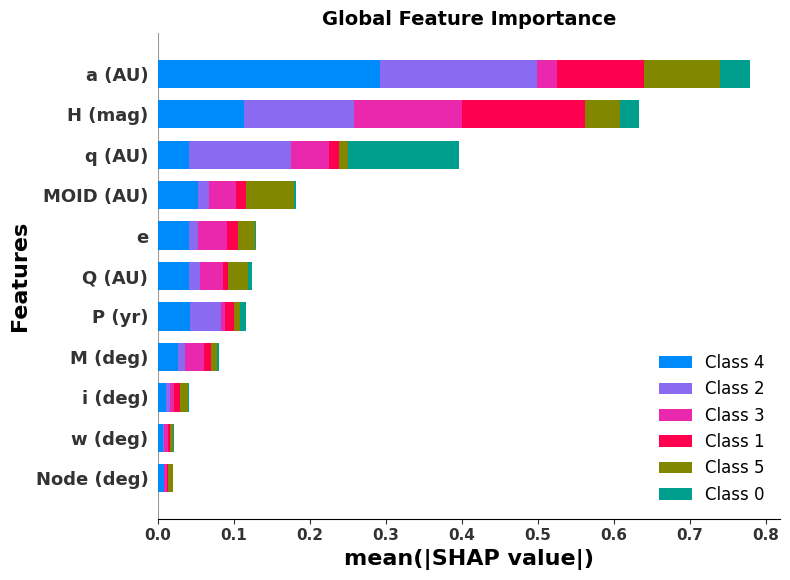

<Figure size 640x480 with 0 Axes>

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import torch
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# ---------------------------
# 3. SHAP Setup
# ---------------------------
feature_names = data.drop("class", axis=1).columns.tolist()

X_test_np = test_X.numpy()
X_subset = X_test_np[:100]

def predict_fn(x):
    return clf_tabnet.predict_proba(x)

background = train_X[:100].numpy()

rng = np.random.default_rng(42)
explainer = shap.KernelExplainer(predict_fn, background)

# Compute SHAP values
shap_values = explainer.shap_values(X_subset)


# ---------------------------
# 5. Summary Plot (Bar)
# ---------------------------
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_subset,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

ax = plt.gca()
ax.set_xlabel("mean(|SHAP value|)", fontweight='bold', fontsize=16)
ax.set_ylabel("Features", fontweight='bold', fontsize=16)
ax.set_title("Global Feature Importance", fontweight='bold', fontsize=14)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight('bold')

plt.tight_layout()
plt.show()
plt.savefig("Global Feature Importance.png", dpi=300, bbox_inches='tight')
plt.savefig("Global Feature Importance.eps", format='eps', dpi=300, bbox_inches='tight')

In [5]:
from shapash.explainer.smart_explainer import SmartExplainer
import pandas as pd
import numpy as np

# Create feature names list
feature_names = data.drop("class", axis=1).columns.tolist()

# Convert test data to DataFrame
X_test_df = pd.DataFrame(test_X.numpy(), columns=feature_names)

# Predict and convert y_pred to a Series with matching index
y_pred_series = pd.Series(clf_tabnet.predict(test_X.numpy()), index=X_test_df.index)

# ✅ Wrapper with _classes attribute for Shapash compatibility
class TabNetWrapper:
    def __init__(self, model):
        self.model = model
        self._classes = list(range(len(np.unique(y_resampled))))  # e.g. [0, 1, 2, ...]

    def predict(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        return self.model.predict(X)

    def predict_proba(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.values
        return self.model.predict_proba(X)

wrapped_tabnet = TabNetWrapper(clf_tabnet)

# Initialize the SmartExplainer with wrapped model
xpl = SmartExplainer(model=wrapped_tabnet)

# Compile the explainer
xpl.compile(
    x=X_test_df,
    y_pred=y_pred_series
)

# Plot feature importance
fig_global = xpl.plot.features_importance()

if fig_global:
    fig_global.update_layout(
        title=dict(font=dict(weight="bold", size=24)),
        xaxis=dict(title=dict(font=dict(weight="bold", size=20)),
                   tickfont=dict(weight="bold", size=16)),
        yaxis=dict(title=dict(font=dict(weight="bold", size=22)),
                   tickfont=dict(weight="bold", size=18)),
        legend=dict(font=dict(weight="bold", size=18)),
        hoverlabel=dict(font=dict(weight="bold", size=18))
    )
    fig_global.show(config={'responsive': True})

INFO: Shap explainer type - shap.explainers.PermutationExplainer()


PermutationExplainer explainer: 1774it [30:53,  1.05s/it]


/tmp/ipykernel_29376/2279488679.py:13: FutureWarning:

The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.



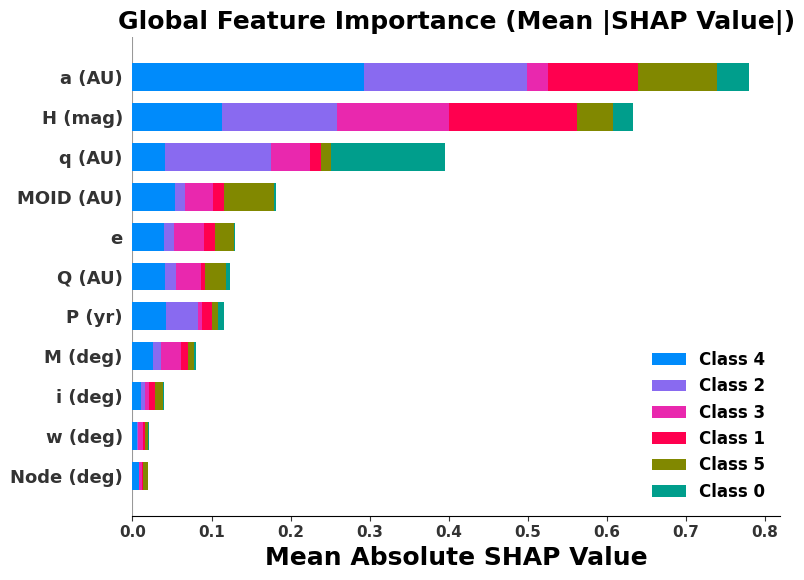

In [ ]:
import matplotlib.pyplot as plt

# Set global text color to black
plt.rcParams.update({
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black"
})

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_test_np,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

# Title and labels (explicitly black)
plt.title("Global Feature Importance (Mean |SHAP Value|)", fontsize=18, color='black')
plt.xlabel("Mean Absolute SHAP Value", fontsize=18, color='black')

plt.tight_layout()

plt.savefig("shap_bar_plot.png", dpi=300, bbox_inches='tight')
plt.savefig("shap_bar_plot.eps", format='eps', dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
plt.savefig("Feature Importance.png", dpi=300, bbox_inches='tight')
plt.savefig("Feature Importance.eps", format='eps', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

Output shape:  (1, 6)
Output sum:    1.0000
Output values: [[2.9414455e-06 3.1898759e-07 5.6567526e-04 5.2182139e-07 9.9877244e-01
  6.5800454e-04]]


<Figure size 1000x600 with 0 Axes>

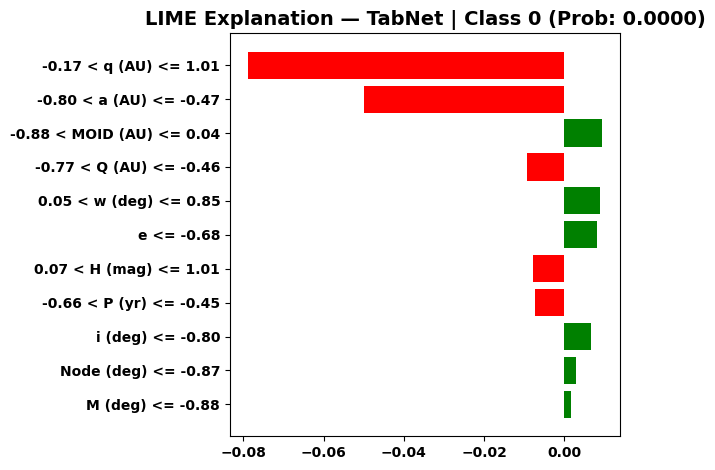

<Figure size 1000x600 with 0 Axes>

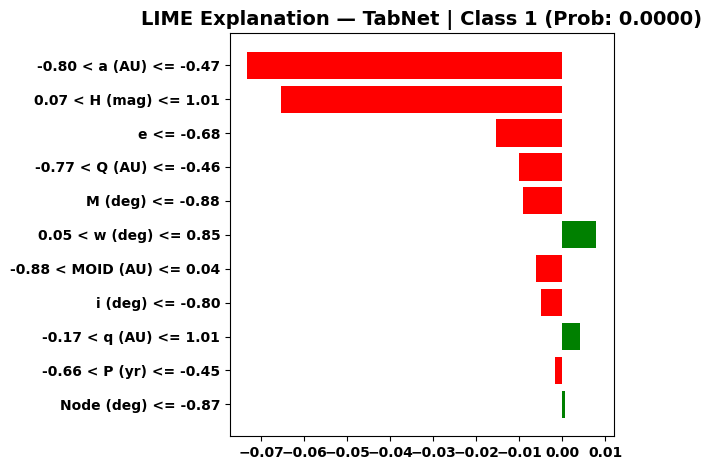

<Figure size 1000x600 with 0 Axes>

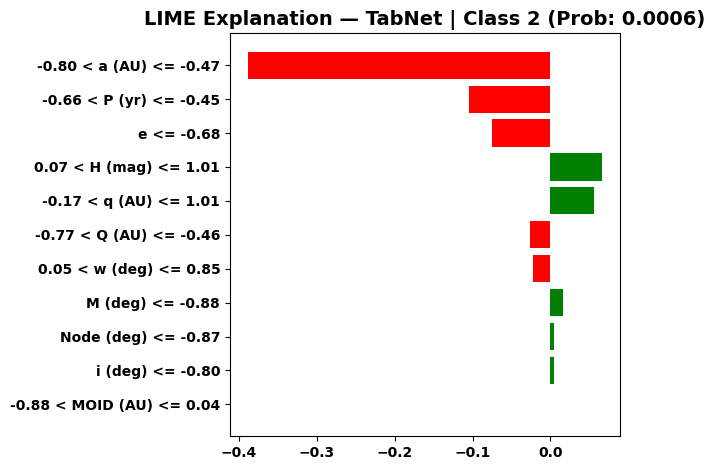

<Figure size 1000x600 with 0 Axes>

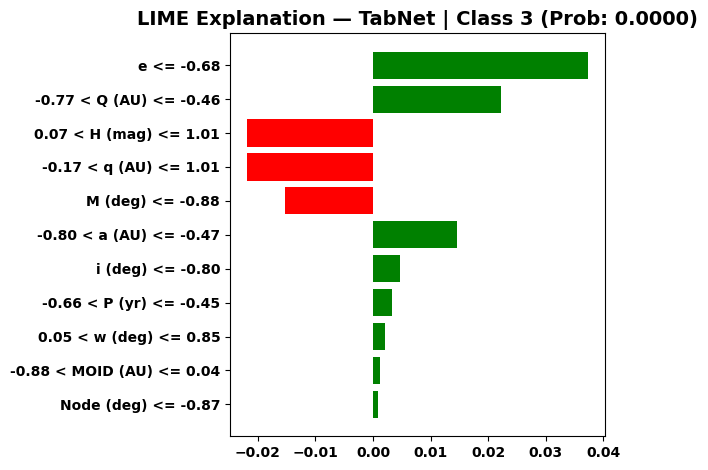

<Figure size 1000x600 with 0 Axes>

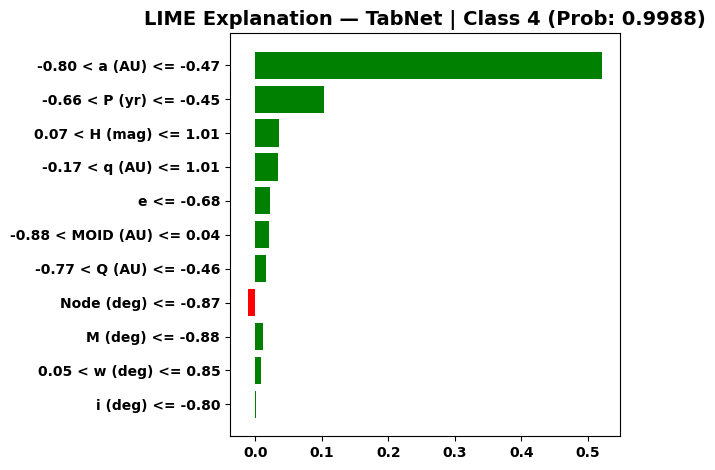

<Figure size 1000x600 with 0 Axes>

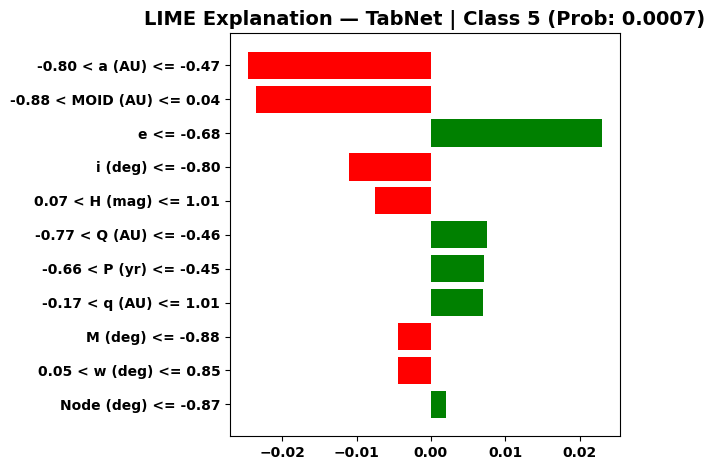

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_tabular

# ── Global Bold Settings ──────────────────────────────────────────────────────
plt.rcParams.update({
    "font.weight":      "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
})

# ── 1. Prepare Data ───────────────────────────────────────────────────────────
feature_names = data.drop("class", axis=1).columns.tolist()
X_train_np    = train_X.numpy()
X_test_np     = test_X.numpy()

# ── 2. TabNet Prediction Function ─────────────────────────────────────────────
def tabnet_predict(X_numpy):
    if X_numpy.ndim == 1:
        X_numpy = X_numpy.reshape(1, -1)       # guard against 1D input
    return clf_tabnet.predict_proba(X_numpy)   # shape: (n_samples, n_classes)

# ── 3. Verify Model Output ────────────────────────────────────────────────────
test_output = tabnet_predict(X_test_np[:1])
print(f"Output shape:  {test_output.shape}")   # expected: (1, n_classes)
print(f"Output sum:    {np.sum(test_output):.4f}")  # expected: ~1.0
print(f"Output values: {test_output}")

n_classes   = test_output.shape[1]
class_names = [f"Class_{i}" for i in range(n_classes)]

# ── 4. Initialize LIME Explainer ──────────────────────────────────────────────
explainer = lime_tabular.LimeTabularExplainer(
    training_data=X_train_np,
    feature_names=feature_names,
    mode="classification",
    class_names=class_names,
    discretize_continuous=True,
    random_state=42                            # reproducibility
)

# ── 5. Explain a Test Instance ────────────────────────────────────────────────
sample_idx = 0

try:
    explanation = explainer.explain_instance(
        data_row=X_test_np[sample_idx],        # single sample (1D array)
        predict_fn=tabnet_predict,
        num_features=len(feature_names),        # show all features
        top_labels=n_classes                    # explain all classes
    )

    # ── 6. Visualize Each Class ───────────────────────────────────────────────
    for cls in range(n_classes):
        fig = plt.figure(figsize=(10, 6))
        explanation.as_pyplot_figure(label=cls)
        ax = plt.gca()

        # ── Force All Text Bold ───────────────────────────────────────────────
        for item in (
            [ax.title, ax.xaxis.label, ax.yaxis.label] +
            ax.get_xticklabels() +
            ax.get_yticklabels()
        ):
            item.set_fontweight("bold")

        for text in ax.texts:                  # LIME bar annotations
            text.set_fontweight("bold")

        # ── Title & Axis Labels ───────────────────────────────────────────────
        ax.set_title(
            f"LIME Explanation — TabNet | Class {cls} "
            f"(Prob: {test_output[0, cls]:.4f})",
            fontweight="bold",
            fontsize=14
        )
        ax.set_xlabel(ax.get_xlabel(), fontweight="bold", fontsize=12)
        ax.set_ylabel(ax.get_ylabel(), fontweight="bold", fontsize=12)

        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontweight("bold")

        plt.tight_layout()

        # ── 7. Save Each Class Figure ─────────────────────────────────────────
        plt.savefig(f"LIME Explanation — TabNet | Class {cls}.png", dpi=300, bbox_inches='tight')
        plt.savefig(f"LIME Explanation — TabNet | Class {cls}.eps", format='eps', dpi=300, bbox_inches='tight')

        plt.show()

except Exception as e:
    print(f"LIME explanation failed: {str(e)}")
    print("\n── Debug Info ──────────────────────────────────────────────────")
    print(f"Sample shape:      {X_test_np[sample_idx].shape}")
    print(f"Prediction shape:  {tabnet_predict(X_test_np[sample_idx:sample_idx+1]).shape}")
    print(f"Prediction values: {tabnet_predict(X_test_np[sample_idx:sample_idx+1])}")

In [7]:
fig_a_AU = xpl.plot.contribution_plot("a (AU)")

if fig_a_AU:
    fig_a_AU.update_layout(
        title=dict(font=dict(weight="bold", size=26)),
        xaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← x-axis tick values
        ),
        yaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← y-axis tick values
        ),
        legend=dict(font=dict(weight="bold", size=22)),
        hoverlabel=dict(font=dict(weight="bold", size=19)),
        coloraxis_colorbar=dict(                                # ← colorbar tick values
            tickfont=dict(size=20, weight="bold"),
            title=dict(font=dict(size=20, weight="bold"))
        )
    )
    fig_a_AU.show()

In [ ]:
fig_e = xpl.plot.contribution_plot("e")

if fig_e:
    fig_e.update_layout(
        title=dict(font=dict(weight="bold", size=26)),
        xaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← x-axis tick values
        ),
        yaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← y-axis tick values
        ),
        legend=dict(font=dict(weight="bold", size=22)),
        hoverlabel=dict(font=dict(weight="bold", size=19)),
        coloraxis_colorbar=dict(                                # ← colorbar tick values
            tickfont=dict(size=20, weight="bold"),
            title=dict(font=dict(size=20, weight="bold"))
        )
    )
    fig_e.show()

In [ ]:
fig_i_deg = xpl.plot.contribution_plot("i (deg)")

# Apply bold styling to the Plotly figure
if fig_i_deg:
    fig_i_deg.update_layout(
        title=dict(font=dict(weight="bold", size=26)),
        xaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← x-axis tick values
        ),
        yaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← y-axis tick values
        ),
        legend=dict(font=dict(weight="bold", size=22)),
        hoverlabel=dict(font=dict(weight="bold", size=19)),
        coloraxis_colorbar=dict(                                # ← colorbar tick values
            tickfont=dict(size=20, weight="bold"),
            title=dict(font=dict(size=20, weight="bold"))
        )
    )
    fig_i_deg.show()

In [ ]:
fig_w_deg = xpl.plot.contribution_plot("w (deg)")

# Apply bold styling to the Plotly figure
if fig_w_deg:
    fig_w_deg.update_layout(
        title=dict(font=dict(weight="bold", size=26)),
        xaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← x-axis tick values
        ),
        yaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← y-axis tick values
        ),
        legend=dict(font=dict(weight="bold", size=22)),
        hoverlabel=dict(font=dict(weight="bold", size=19)),
        coloraxis_colorbar=dict(                                # ← colorbar tick values
            tickfont=dict(size=20, weight="bold"),
            title=dict(font=dict(size=20, weight="bold"))
        )
    )
    fig_w_deg.show()

In [ ]:
fig_node_deg = xpl.plot.contribution_plot("Node (deg)")

# Apply bold styling to the Plotly figure
if fig_node_deg:
    fig_node_deg.update_layout(
        title=dict(font=dict(weight="bold", size=26)),
        xaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← x-axis tick values
        ),
        yaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← y-axis tick values
        ),
        legend=dict(font=dict(weight="bold", size=22)),
        hoverlabel=dict(font=dict(weight="bold", size=19)),
        coloraxis_colorbar=dict(                                # ← colorbar tick values
            tickfont=dict(size=20, weight="bold"),
            title=dict(font=dict(size=20, weight="bold"))
        )
    )
    fig_node_deg.show()

In [ ]:
fig_m_deg = xpl.plot.contribution_plot("M (deg)")

# Apply bold styling to the Plotly figure
if fig_m_deg:
    fig_m_deg.update_layout(
        title=dict(font=dict(weight="bold", size=26)),
        xaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← x-axis tick values
        ),
        yaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← y-axis tick values
        ),
        legend=dict(font=dict(weight="bold", size=22)),
        hoverlabel=dict(font=dict(weight="bold", size=19)),
        coloraxis_colorbar=dict(                                # ← colorbar tick values
            tickfont=dict(size=20, weight="bold"),
            title=dict(font=dict(size=20, weight="bold"))
        )
    )
    fig_m_deg.show()

In [ ]:
fig_q_AU = xpl.plot.contribution_plot("q (AU)")

# Apply bold styling to the Plotly figure
if fig_q_AU:
    fig_q_AU.update_layout(
       title=dict(font=dict(weight="bold", size=26)),
        xaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← x-axis tick values
        ),
        yaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← y-axis tick values
        ),
        legend=dict(font=dict(weight="bold", size=22)),
        hoverlabel=dict(font=dict(weight="bold", size=19)),
        coloraxis_colorbar=dict(                                # ← colorbar tick values
            tickfont=dict(size=20, weight="bold"),
            title=dict(font=dict(size=20, weight="bold"))
        )
    )
    fig_q_AU.show()

In [ ]:
fig_Q_AU = xpl.plot.contribution_plot("Q (AU)")

# Apply bold styling to the Plotly figure
if fig_Q_AU:
    fig_Q_AU.update_layout(
       title=dict(font=dict(weight="bold", size=26)),
        xaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← x-axis tick values
        ),
        yaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← y-axis tick values
        ),
        legend=dict(font=dict(weight="bold", size=22)),
        hoverlabel=dict(font=dict(weight="bold", size=19)),
        coloraxis_colorbar=dict(                                # ← colorbar tick values
            tickfont=dict(size=20, weight="bold"),
            title=dict(font=dict(size=20, weight="bold"))
        )
    )
    fig_Q_AU.show()

In [ ]:
fig_P_yr = xpl.plot.contribution_plot("P (yr)")

# Apply bold styling to the Plotly figure
if fig_P_yr:
    fig_P_yr.update_layout(
        title=dict(font=dict(weight="bold", size=26)),
        xaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← x-axis tick values
        ),
        yaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← y-axis tick values
        ),
        legend=dict(font=dict(weight="bold", size=22)),
        hoverlabel=dict(font=dict(weight="bold", size=19)),
        coloraxis_colorbar=dict(                                # ← colorbar tick values
            tickfont=dict(size=20, weight="bold"),
            title=dict(font=dict(size=20, weight="bold"))
            )
    )
    fig_P_yr.show()

In [ ]:
fig_H_mag = xpl.plot.contribution_plot("H (mag)")

# Apply bold styling to the Plotly figure
if fig_H_mag:
    fig_H_mag.update_layout(
        title=dict(font=dict(weight="bold", size=26)),
        xaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← x-axis tick values
        ),
        yaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← y-axis tick values
        ),
        legend=dict(font=dict(weight="bold", size=22)),
        hoverlabel=dict(font=dict(weight="bold", size=19)),
        coloraxis_colorbar=dict(                                # ← colorbar tick values
            tickfont=dict(size=20, weight="bold"),
            title=dict(font=dict(size=20, weight="bold"))
        )
    )
    fig_H_mag.show()

In [ ]:
fig_MOID_AU = xpl.plot.contribution_plot("MOID (AU)")

# Apply bold styling to the Plotly figure
if fig_MOID_AU:
    fig_MOID_AU.update_layout(
        title=dict(font=dict(weight="bold", size=26)),
        xaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← x-axis tick values
        ),
        yaxis=dict(
            title=dict(font=dict(weight="bold", size=24)),
            tickfont=dict(weight="bold", size=24)               # ← y-axis tick values
        ),
        legend=dict(font=dict(weight="bold", size=22)),
        hoverlabel=dict(font=dict(weight="bold", size=19)),
        coloraxis_colorbar=dict(                                # ← colorbar tick values
            tickfont=dict(size=20, weight="bold"),
            title=dict(font=dict(size=20, weight="bold"))
        )
    )
    fig_MOID_AU.show()

In [ ]:
fig_local_plot= xpl.plot.local_plot(index=1362)
# Display the Plotly figure and make text bold
if fig_local_plot:
    # Update layout to make relevant text elements bold
    fig_local_plot.update_layout(
        title=dict(font=dict(weight="bold")),
        xaxis=dict(title=dict(font=dict(weight="bold", size= 24)), tickfont=dict(weight="bold")),
        yaxis=dict(title=dict(font=dict(weight="bold", size= 24)), tickfont=dict(weight="bold")),
        legend=dict(font=dict(weight="bold")),
        hoverlabel=dict(font=dict(weight="bold")) # For hover text
    )
    fig_local_plot.show()

In [ ]:
fig_local_plot_2= xpl.plot.local_plot(index=5)
# Display the Plotly figure and make text bold
if fig_local_plot_2:
    # Update layout to make relevant text elements bold
    fig_local_plot_2.update_layout(
        title=dict(font=dict(weight="bold")),
        xaxis=dict(title=dict(font=dict(weight="bold", size= 24)), tickfont=dict(weight="bold")),
        yaxis=dict(title=dict(font=dict(weight="bold", size= 24)), tickfont=dict(weight="bold")),
        legend=dict(font=dict(weight="bold")),
        hoverlabel=dict(font=dict(weight="bold")) # For hover text
    )
    fig_local_plot_2.show()